# PJ

In [3]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ast

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


#import statsmodels.api as s

# Clean DATA

In [29]:
# Read Data
df = pd.read_csv('listings.csv.gz')
df.shape

(30259, 90)

In [ ]:
# df.drop(columns=['id','listing_url','scrape_id', 'picture_url', 'host_id','last_scraped','hosts_time_as_user_months','hosts_time_as_host_months','license', 'host_thumbnail_url','host_picture_url', 'host_has_profile_pic', 'host_identity_verified','neighbourhood','price_quote_raw','minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'calendar_updated', 'calendar_last_scraped', 'number_of_reviews_l30d', 'license', 'instant_bookable', 'calculated_host_listings_count_entire_homes' ,'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms','host_about','host_location','description','host_name','hosts_time_as_user_years','description','host_name','host_neighbourhood','host_since','host_response_time','host_response_rate','host_acceptance_rate','host_total_listings_count','host_verifications' ,"bathrooms_text", "price_quote_total_price","price_quote_price_per_night", "estimated_revenue_l365d","neighborhood_overview"], inplace=True)

# df[['source', 'name', 'host_url', 'host_profile_id', 'host_profile_url','hosts_time_as_host_years', 'host_is_superhost', 'host_listings_count','neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms','bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date','price_quote_checkout_date', 'minimum_nights_avg_ntm','maximum_nights_avg_ntm', 'has_availability', 'availability_30','availability_60', 'availability_90', 'availability_365','number_of_reviews', 'number_of_reviews_ltm', 'availability_eoy',       'number_of_reviews_ly', 'estimated_occupancy_l365d', 'first_review',       'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin','review_scores_communication', 'review_scores_location','review_scores_value', 'calculated_host_listings_count',  'reviews_per_month']].isna().all()

# df.to_csv("dataset.csv", index=False)

In [4]:
df = pd.read_csv('dataset.csv')
df.shape

(30259, 44)

In [5]:
df['price'].isna().sum() # check missing values in price column
df = df.dropna(subset=["price"]) # removes rows where "price" column has missing values (NaN)
df.shape

(21515, 44)

# EDA

In [22]:
df = pd.read_csv('cleaned_dataset_2.csv')
df.info()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21515 entries, 0 to 21514
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   neighbourhood_cleansed        21515 non-null  object 
 1   neighbourhood_group_cleansed  21515 non-null  object 
 2   latitude                      21515 non-null  float64
 3   longitude                     21515 non-null  float64
 4   room_type                     21515 non-null  object 
 5   accommodates                  21515 non-null  int64  
 6   bathrooms                     19144 non-null  float64
 7   bedrooms                      13980 non-null  float64
 8   beds                          19775 non-null  float64
 9   price                         21515 non-null  float64
 10  review_scores_rating          15438 non-null  float64
 11  review_scores_cleanliness     15438 non-null  float64
 12  review_scores_location        15437 non-null  float64
 13  a

,neighbourhood_cleansed,neighbourhood_group_cleansed,room_type
count,21515,21515,21515
unique,222,5,4
top,Bedford-Stuyvesant,Manhattan,Entire home/apt
freq,1506,9539,11537


## 1. Is the dataset clean? (Missing values)

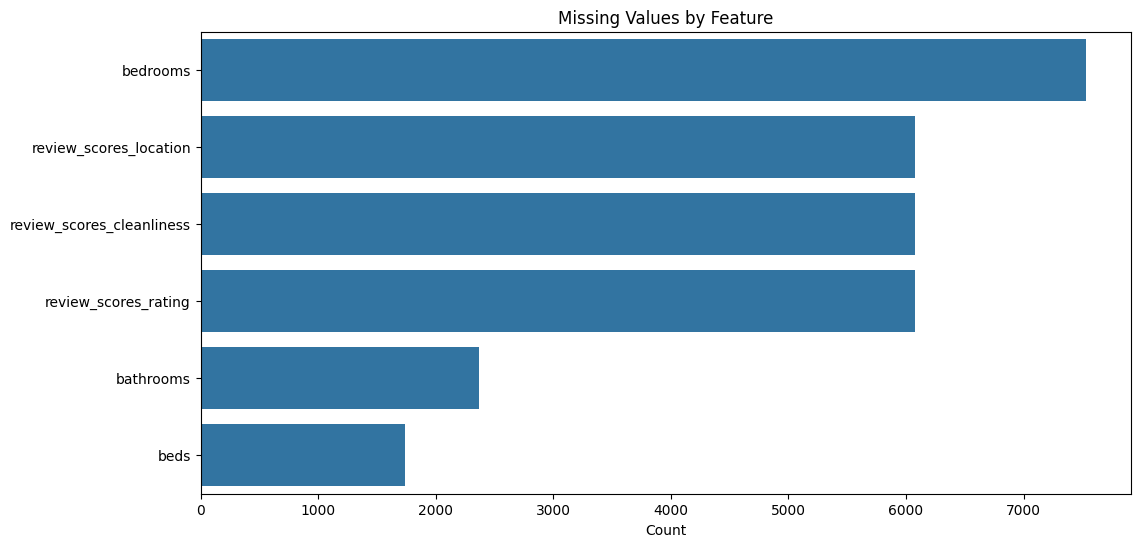

In [23]:
missing = (df.isnull().sum().sort_values(ascending=False))

missing = missing[missing > 0]

plt.figure(figsize=(12,6))
sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

## 2. What does the target variable look like? (Price distribution)

In [ ]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df["price"].dtype

dtype('float64')

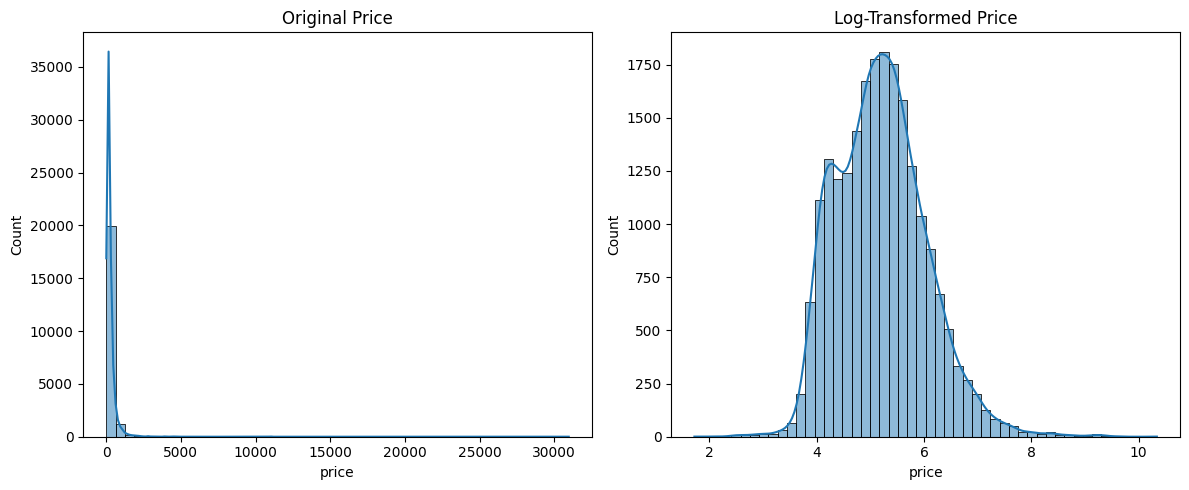

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Original Price")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Log-Transformed Price")

plt.tight_layout()
plt.show()

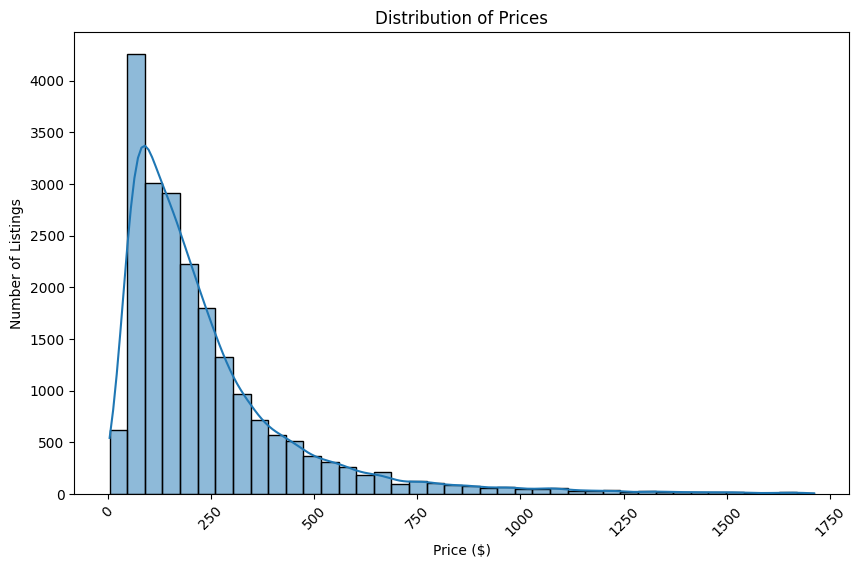

In [11]:
upper = df["price"].quantile(0.99) # removes outliers

plt.figure(figsize=(10,6))

sns.histplot(
    df.loc[df["price"] <= upper, "price"],
    bins=40,
    kde=True)
plt.xticks(rotation=45)
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Prices")

plt.show()

Since distribution is right-skewed, a log transformation might be appropriate.

## 3. Are there extreme prices? (Boxplot)

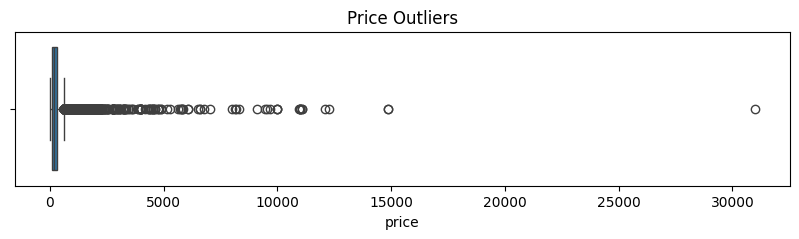

In [15]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["price"]
)

plt.title("Price Outliers")
plt.show()


## 4. Which numerical features are related? (Correlation heatmap)

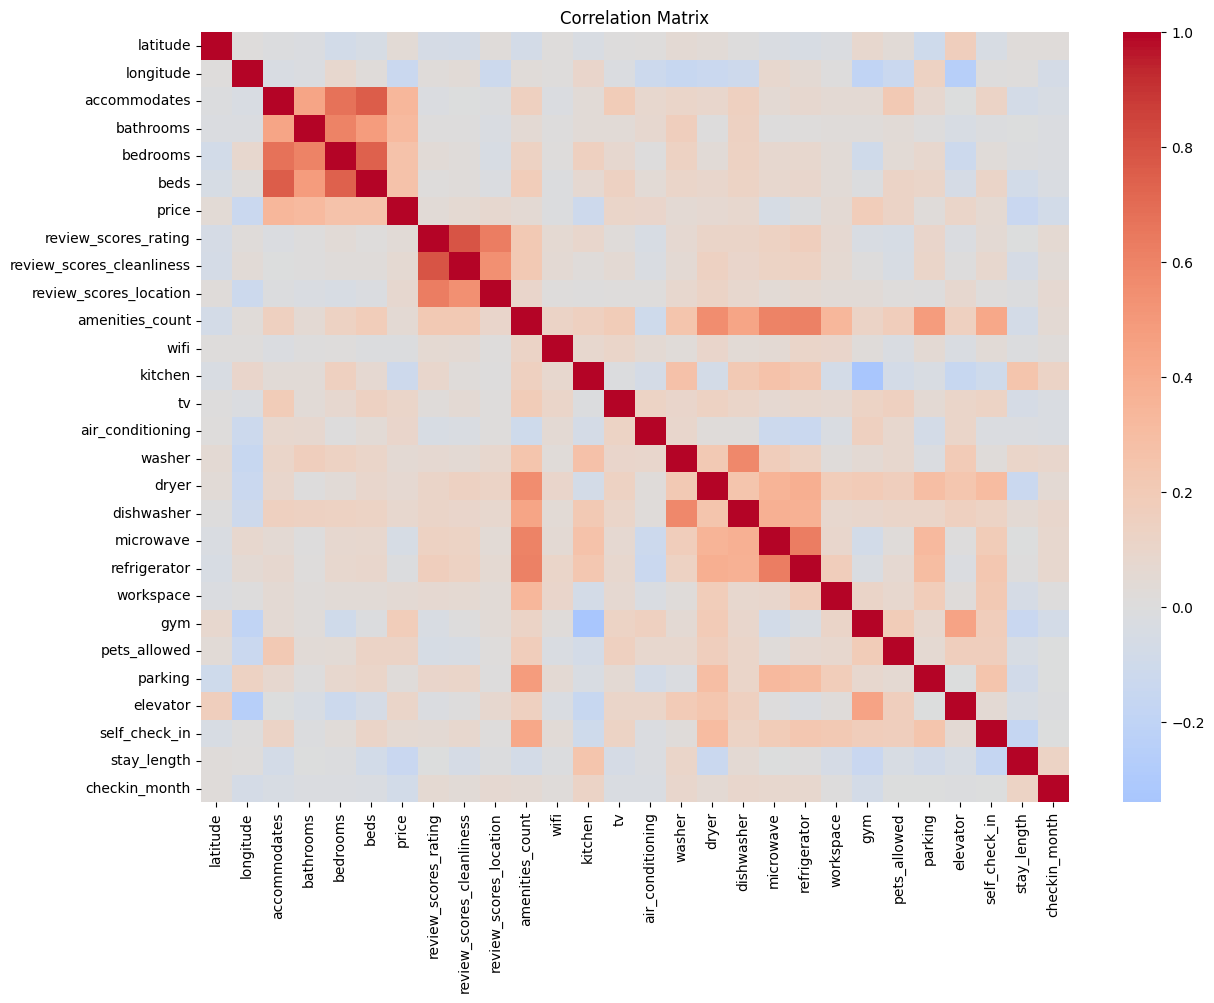

In [16]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## 5. Does room type affect price? (Room type boxplot)

In [25]:
df2 = df[df["price"] <10000.0] # removes outliers
df2['price'].max()


np.float64(9690.48)

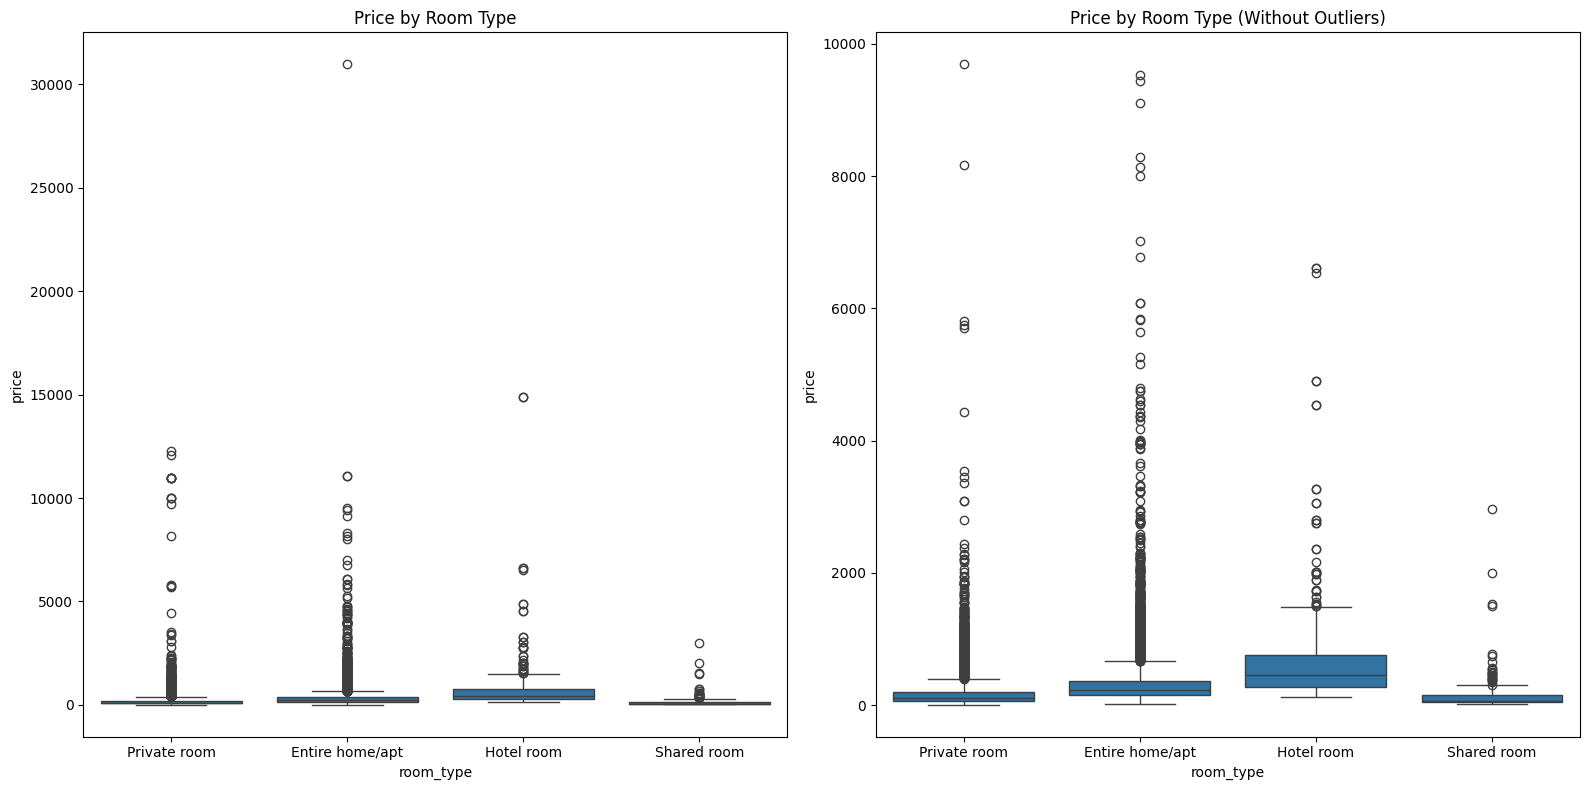

In [28]:
# 1-row, 2-column grid.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# First dataframe on the left axis (axes[0])
sns.boxplot(
    data=df,
    x="room_type",
    y="price",
    ax=axes[0]
)
axes[0].set_title("Price by Room Type")

# Second dataframe on the right axis (axes[1])
sns.boxplot(
    data=df2,
    x="room_type",
    y="price",
    ax=axes[1]
)
axes[1].set_title("Price by Room Type (Without Outliers)")

# 4. Clean up the layout and display
plt.tight_layout()
plt.show()


## 6. Which neighborhoods are the most expensive? (Average price by neighborhood)


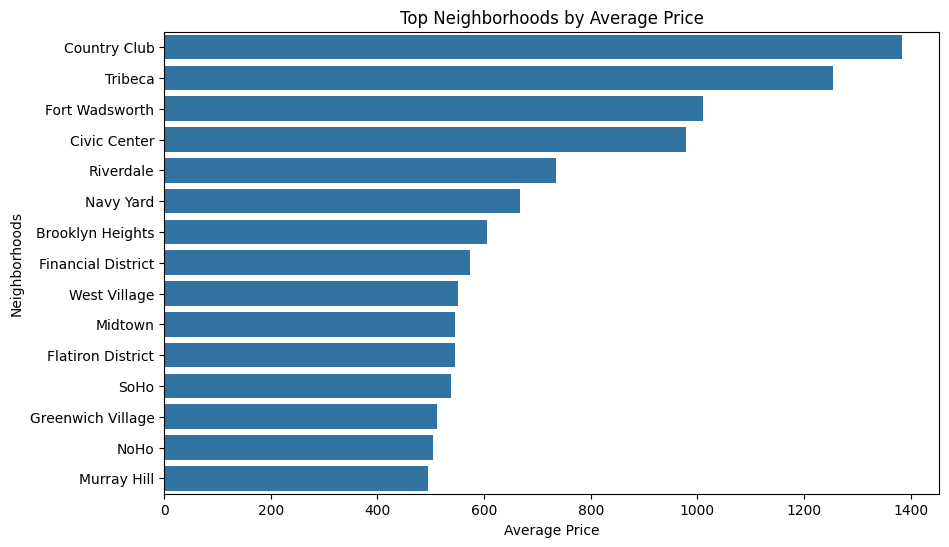

In [39]:
avg_price = (
    df.groupby("neighbourhood_cleansed")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index
)

plt.title("Top Neighborhoods by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Neighborhoods")
plt.show()

## 7. Do larger properties cost more? (Bedrooms vs. price)


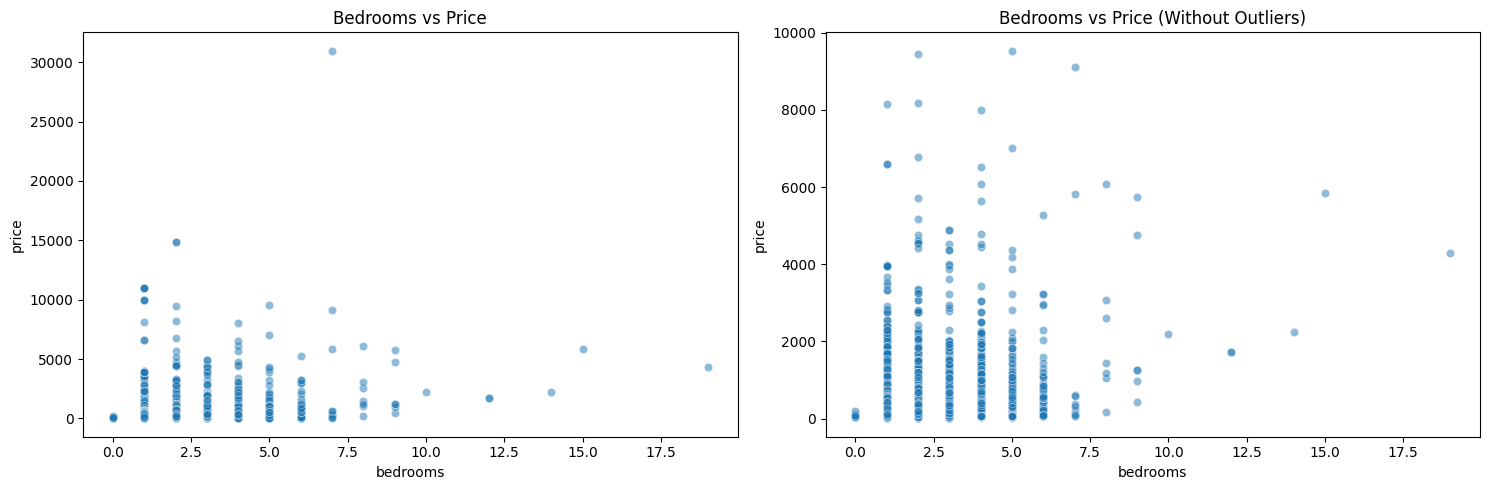

In [47]:
# 1-row, 2-column grid.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# First dataframe on the left axis (axes[0])
sns.scatterplot(
    data=df,
    x="bedrooms",
    y="price",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Bedrooms vs Price")

# Second dataframe on the right axis (axes[1])
sns.scatterplot(
    data=df2,
    x="bedrooms",
    y="price",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Bedrooms vs Price (Without Outliers)")

# 4. Clean up the layout and display
plt.tight_layout()
plt.show()

## 8. Do better reviews correlate with higher prices? (Review rating vs. price)


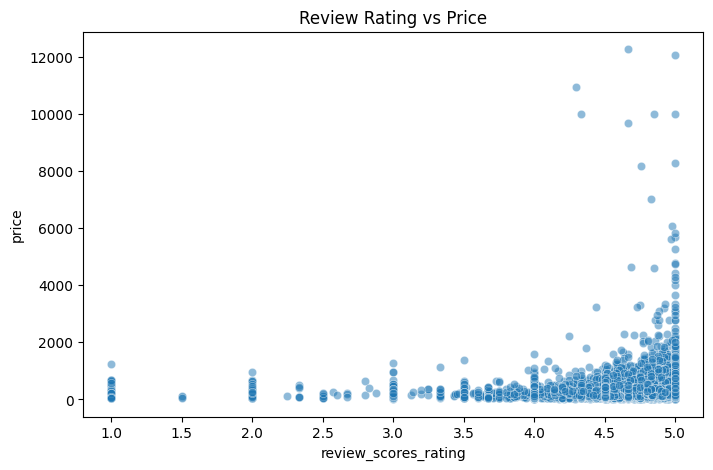

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="review_scores_rating",
    y="price",
    alpha=0.5
)

plt.title("Review Rating vs Price")
plt.show()

## 9. Where are expensive listings located? (Latitude/longitude map)

In [51]:
fig = px.density_map(
    df,
    lat="latitude",
    lon="longitude",
    z="price",
    radius=20,
    zoom=10,
    height=700,
    title="Airbnb Price Heatmap"
)

fig.show()

# Feature Engineering

In [ ]:
pd.set_option('display.max_colwidth', None)
print(df.iloc[0]['amenities'])

["Bed linens", "Hot water", "Exterior security cameras on property", "Cleaning products", "Fire extinguisher", "Elevator", "Lockbox", "Microwave", "Laundromat nearby", "Oven", "Portable fans", "Self check-in", "Paid parking off premises", "Kitchen", "Free street parking", "Dining table", "Long term stays allowed", "Hair dryer", "Body soap", "Extra pillows and blankets", "Washer", "Backyard", "Dryer", "Iron", "Bikes", "Ceiling fan", "Carbon monoxide alarm", "Dishes and silverware", "Freezer", "Stove", "Heating", "Coffee maker", "Luggage dropoff allowed", "Conditioner", "Bathtub", "Wine glasses", "Clothing storage", "Fast wifi \u2013 330 Mbps", "Cleaning available during stay", "Blender", "Shower gel", "Smoke alarm", "Cooking basics", "Refrigerator", "Hangers", "Single level home", "Dedicated workspace", "Essentials", "Shampoo"]


In [6]:
df['amenities'].value_counts().head(5)

amenities
["TV", "Air conditioning", "Wifi", "Kitchen", "Smoke alarm", "Carbon monoxide alarm", "Washer"]                                                                                                                                                                                                                                                                                       168
["TV", "Air conditioning", "Wifi", "Kitchen", "Smoke alarm", "Carbon monoxide alarm"]                                                                                                                                                                                                                                                                                                  98
["TV", "Air conditioning", "Exercise equipment", "Wifi", "Kitchen", "Smoke alarm", "Carbon monoxide alarm", "Washer"]                                                                                                                     

In [7]:
df['amenities'].dtypes

dtype('O')

In [8]:
def count_amenities(x):
    try:
        return len(ast.literal_eval(x))
    except:
        return 0

df["amenities_count"] = df["amenities"].apply(count_amenities)
df["amenities_count"].head(5)

0    49
1    26
2    18
3    22
4    50
Name: amenities_count, dtype: int64

In [9]:
important_amenities = {
    "wifi": "wifi",
    "kitchen": "kitchen",
    "tv": "tv",
    "air_conditioning": "air conditioning",
    "heating": "heating",
    "washer": "washer",
    "dryer": "dryer",
    "dishwasher": "dishwasher",
    "microwave": "microwave",
    "refrigerator": "refrigerator",
    "coffee_maker": "coffee maker",
    "workspace": "dedicated workspace",
    "gym": "gym",
    "pets_allowed": "pets allowed",
    "parking": "parking",
    "elevator": "elevator",
    "self_check_in": "self check-in"}


def extract_amenities(amenities):
    try:
        amenities = [a.lower() for a in ast.literal_eval(amenities)]
    except:
        amenities = []

    return {
        feature: int(any(keyword in amenity for amenity in amenities))
        for feature, keyword in important_amenities.items()
    }


amenity_df = (
    df["amenities"]
    .apply(extract_amenities)
    .apply(pd.Series)
)

df = pd.concat([df, amenity_df], axis=1)

In [10]:
df[[
    "amenities_count",
    "wifi",
    "kitchen",
    "tv",
    "air_conditioning",
    "gym",
    "parking",
    "pets_allowed"
]].head()

,amenities_count,wifi,kitchen,tv,air_conditioning,gym,parking,pets_allowed
0,49,1,1,0,0,0,1,0
1,26,1,1,1,1,0,1,0
2,18,1,1,0,0,0,1,0
3,22,1,1,1,1,0,1,0
4,50,1,1,1,1,0,1,0


In [11]:
df = df.drop(columns="amenities") # drop the original amenities column

In [13]:
df.to_csv("data_feature_eng.csv", index=False) # save

In [ ]:
df= pd.read_csv('data_feature_eng.csv')
df

In [ ]:
# Change Price colmun to float
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float))

# Convert to Date Columns 
date_cols = [
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "first_review",
    "last_review"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Booking length
df["stay_length"] = (
    df["price_quote_checkout_date"] -
    df["price_quote_checkin_date"]
).dt.days

# Extract booking month
df["checkin_month"] = df["price_quote_checkin_date"].dt.month


df = df.drop(columns=[
    "bathrooms_text",
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "first_review",
    "last_review",
    "price_quote_price_per_night",  # similar values to Price column
    "price_quote_total_price", 
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d"
])

In [ ]:
cols_to_remove = [
    "hosts_time_as_host_years",
    "host_is_superhost",
    "host_listings_count",
    "property_type",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_ly",
    "reviews_per_month",
    "calculated_host_listings_count",
    "review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_value",
    "coffee_maker",
    "heating",'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm','has_availability'
]

df2 = df.drop(columns=cols_to_remove)

In [175]:
df2.shape

(21515, 31)

In [176]:
df2.to_csv("cleaned_dataset_2.csv", index=False) # save

# Data Preprocessing

In [58]:
# Features
X = df2.drop(columns="price")

# Target
y = np.log1p(df2["price"])

In [59]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget:")
print(y.head())

X shape: (21500, 30)
y shape: (21500,)

Target:
0    4.744671
1    4.772970
2    4.395190
3    4.358886
4    5.315519
Name: price, dtype: float64


In [61]:
# Numerical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical Features:", len(numeric_features))
print(numeric_features)

print("\nCategorical Features:", len(categorical_features))
print(categorical_features)

Numerical Features: 27
['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'amenities_count', 'wifi', 'kitchen', 'tv', 'air_conditioning', 'washer', 'dryer', 'dishwasher', 'microwave', 'refrigerator', 'workspace', 'gym', 'pets_allowed', 'parking', 'elevator', 'self_check_in', 'stay_length', 'checkin_month']

Categorical Features: 3
['neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'room_type']


# Train/Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17200, 30)
X_test : (4300, 30)
y_train: (17200,)
y_test : (4300,)


In [63]:
# We'll create two separate pipelines: Numerical Pipeline and Categorical Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(17200, 254)
(4300, 254)


# Build the Baseline Model (Linear Regression)

In [77]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_log = linear_model.predict(X_test)

In [78]:
# Convert to original scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Evaluate
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)


print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

# Start of comparison table

results = []
results.append({
    "Model": "Linear Regression(log)",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

MAE : 111.25
RMSE: 386.05
R²  : 0.326


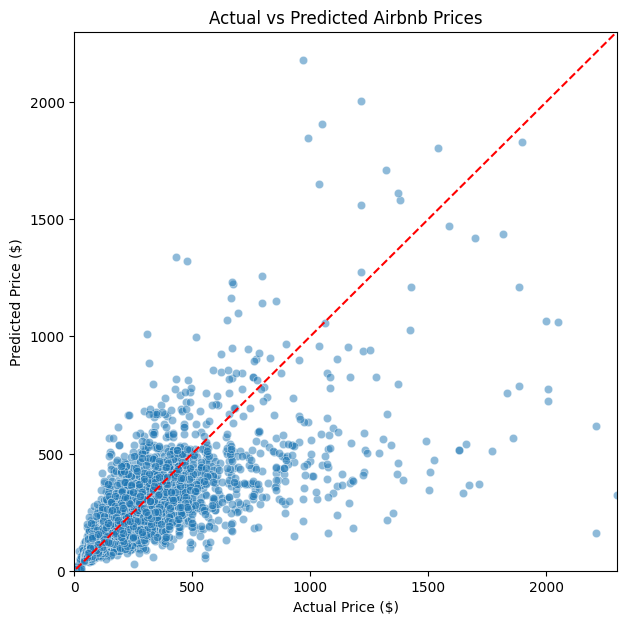

In [85]:
# Convert back to original price scale

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_true,
    y=y_pred,
    alpha=0.5
)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    color="red",
    linestyle="--"
)

plt.xlim(0, 2300)
plt.ylim(0, 2300)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

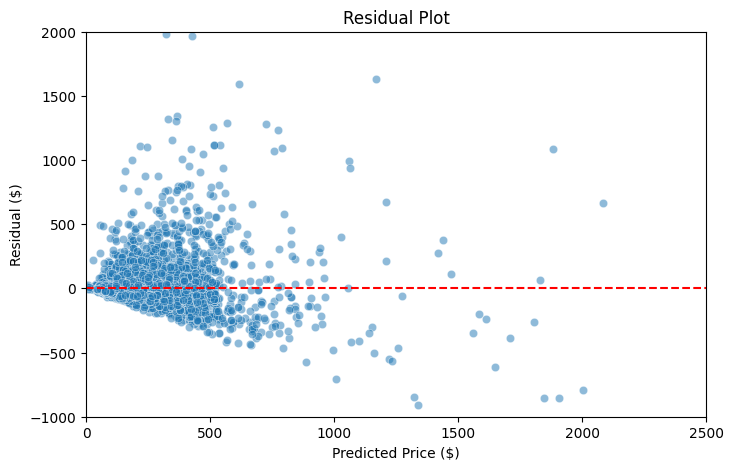

In [90]:
residuals = y_true - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")
plt.xlim(0, 2500)
plt.ylim(-1000, 2000)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Plot")

plt.show()

In [91]:
X.to_csv("X_train.csv", index=False)


# Ridge Regression (Log-Transformed Price)
Reduces overfitting, and handles correlated predictors well.

In [92]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])
# Train model
ridge_model.fit(X_train, y_train)

# Predict on log scale
y_pred_log = ridge_model.predict(X_test)

# Convert back to original price scale
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

# Evaluate
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

results.append({
    "Model": "Ridge Regression (log)",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

MAE : 111.19
RMSE: 386.91
R²  : 0.323


# Lasso Regression

Shrinks some coefficients all the way to zero, effectively performing feature selection.

In [93]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.001, random_state=42))
])

lasso_model.fit(X_train, y_train)

y_pred_log = lasso_model.predict(X_test)

y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")


results.append({
    "Model": "Lasso Regression (log)",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

MAE : 112.32
RMSE: 389.40
R²  : 0.314


# Elastic Net
Combines Ridge and Lasso, giving you the benefits of both.

In [95]:

elastic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        random_state=42
    ))
])

elastic_model.fit(X_train, y_train)

y_pred_log = elastic_model.predict(X_test)

y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

results.append({
    "Model": "Elastic Net",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})

MAE : 111.69
RMSE: 388.64
R²  : 0.317


# Random Forest Regressor 
Random Forest can learn nonlinear relationships.
Testing to see if Random Forest improves R²

In [96]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_log = rf_model.predict(X_test)
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)


mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

results.append({
    "Model": "Random Forest Regressor",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})


MAE : 86.92
RMSE: 347.89
R²  : 0.453


Random Forest is the clear winner. Compared with Linear Regression:
- MAE decreases $111.25 → $86.92 about a 22% reduction in avg prediction error.
- RMSE decreases 386 → 348
- R² increases 0.326 → 0.453
That's a substantial improvement.

# Hyperparameter Tuning

In [98]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': None}


In [100]:
best_rf = random_search.best_estimator_

y_pred_log = best_rf.predict(X_test)

y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

results.append({
    "Model": " Tuned Random Forest Regressor",  
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
})


MAE : 87.54
RMSE: 350.75
R²  : 0.444


Hyperparameter tuning was performed using RandomizedSearchCV with 5-fold cross-validation. Although the tuned model produced similar performance, the default Random Forest achieved slightly lower MAE and RMSE and was therefore selected as the final model.

# Model Evaluation

In [111]:
results1 = pd.DataFrame(results)
print(results1)

                            Model         MAE        RMSE        R2
0          Linear Regression(log)  111.251078  386.054707  0.325845
1          Ridge Regression (log)  111.193708  386.913767  0.322841
2          Lasso Regression (log)  112.319705  389.398423  0.314116
3                     Elastic Net  111.690665  388.641056  0.316782
4         Random Forest Regressor   86.916806  347.885140  0.452563
5   Tuned Random Forest Regressor   87.538906  350.750050  0.443510


# Feature Importance
Understand which features drive predictions.
Since the model is a pipeline, use the fitted preprocessor to recover the feature names after one-hot encoding.

                        Feature  Importance
2                  Accommodates    0.232633
25                  Stay Length    0.188126
1                     Longitude    0.106087
250  Room Type: Entire Home/Apt    0.092569
0                      Latitude    0.060777
3                     Bathrooms    0.051475
26                Checkin Month    0.045253
9               Amenities Count    0.028821
4                      Bedrooms    0.025210
20                          Gym    0.022739
7     Review Scores Cleanliness    0.013647
6          Review Scores Rating    0.013120
8        Review Scores Location    0.012286
252     Room Type: Private Room    0.007820
5                          Beds    0.007346
16                   Dishwasher    0.006495
247     Neighborhood: Manhattan    0.006386
12                           Tv    0.005329
21                 Pets Allowed    0.003965
14                       Washer    0.003430


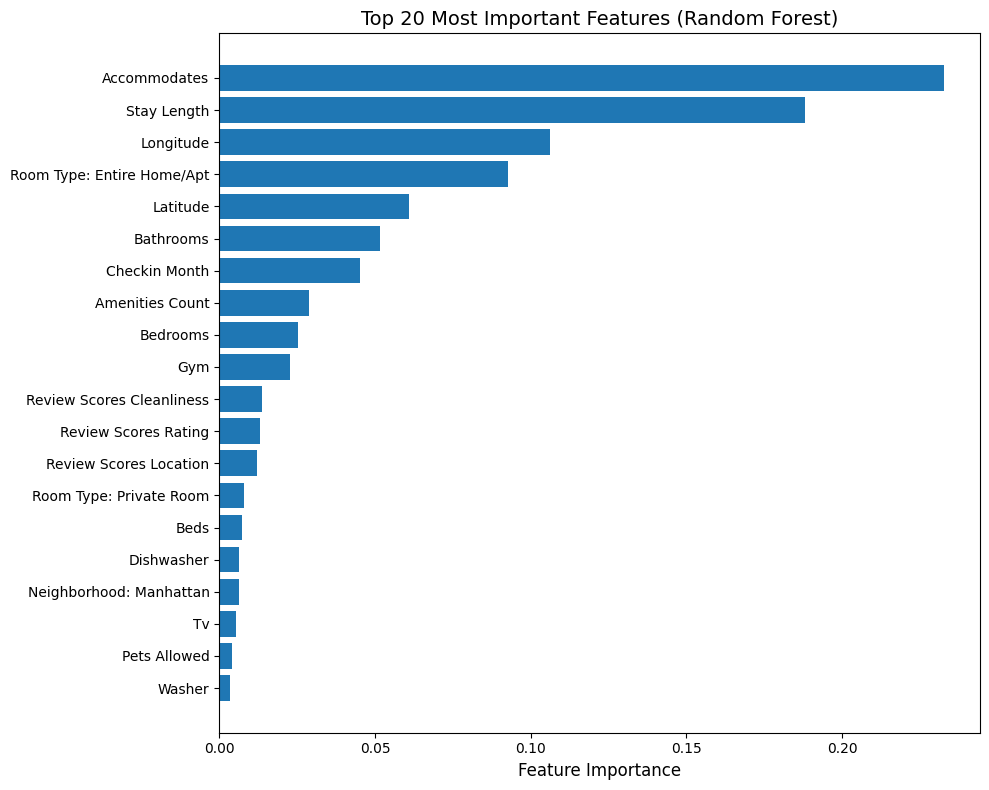

In [119]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances from the Random Forest
importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

# Clean feature names
importance_df["Feature"] = (
    importance_df["Feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
        .str.replace("room_type_", "Room Type: ", regex=False)
        .str.replace("neighbourhood_group_cleansed_", "Neighborhood: ", regex=False)
        .str.replace("neighbourhood_cleansed_", "", regex=False)
        .str.replace("_", " ")
        .str.title()
)

# Display top 20 features
print(importance_df.head(20))

# Plot Top 20 Feature Importances
plt.figure(figsize=(10, 8))

top20 = importance_df.head(20)

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("")
plt.title("Top 20 Most Important Features (Random Forest)", fontsize=14)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Save Model

In [133]:
import joblib
joblib.dump(rf_model,"airbnb_price_predictor.pkl")
joblib.dump(X_train.columns,"model_features.pkl")

importance_df.to_csv("feature_importance.csv", index=False)
results1.to_csv("model_comparison.csv", index=False)

In [134]:
results1

,Model,MAE,RMSE,R2
0,Linear Regression(log),111.251078,386.054707,0.325845
1,Ridge Regression (log),111.193708,386.913767,0.322841
2,Lasso Regression (log),112.319705,389.398423,0.314116
3,Elastic Net,111.690665,388.641056,0.316782
4,Random Forest Regressor,86.916806,347.885140,0.452563
5,Tuned Random Forest Regressor,87.538906,350.750050,0.443510
